In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.units import dbm_to_w, w_to_dbm

import rfmodel.rf.registry


cfg = load_yaml(r".\PA_test.yaml")
pipe = pipeline_from_config(cfg)

# Using Rapp Model

In [2]:
fs = 5_000_000
fc = 1e9
f0 = 50_000
dur = 0.02
t = np.arange(0, dur, 1 / fs)


# ------------------------------------------------------------
# 1) Small-signal gain check
# ------------------------------------------------------------
Pin_dbm = 0.0
Pin_W = dbm_to_w(Pin_dbm)

A = np.sqrt(Pin_W)
x_in = A * np.exp(1j * 2 * np.pi * f0 * t)

sig_in = Signal(
    x=x_in,
    fs_hz=fs,
    fc_hz=fc,
    meta={"Pin_dbm": Pin_dbm},
)

sig_out_rapp, taps = pipe.run(sig_in, taps=["pa1"])


In [3]:
Pin_meas_W = np.mean(np.abs(sig_in.x) ** 2)
Pout_meas_W = np.mean(np.abs(sig_out_rapp.x) ** 2)

G_lin = Pout_meas_W / Pin_meas_W
G_db = 10 * np.log10(G_lin)

print("=== Small-signal test ===")
print("Input power  (W):  ", Pin_meas_W)
print("Input power  (dBm):", w_to_dbm(Pin_meas_W))
print("Output power (W):  ", Pout_meas_W)
print("Output power (dBm):", w_to_dbm(Pout_meas_W))
print("Measured gain (dB):", G_db)


=== Small-signal test ===
Input power  (W):   0.0009999999999999998
Input power  (dBm): -9.643274665532871e-16
Output power (W):   0.09999567600564402
Output power (dBm): 19.999812207251036
Measured gain (dB): 19.99981220725104


In [4]:
# ------------------------------------------------------------
# 2) Compression sweep
# ------------------------------------------------------------
Pin_sweep_dbm = np.linspace(-30, 25, 51)
Pout_sweep_dbm = []
Gain_sweep_db = []
Pout_ideal_dbm = []

for Pin_dbm_i in Pin_sweep_dbm:
    Pin_W_i = dbm_to_w(Pin_dbm_i)
    A_i = np.sqrt(Pin_W_i)

    x_i = A_i * np.exp(1j * 2 * np.pi * f0 * t)
    sig_i = Signal(
        x=x_i,
        fs_hz=fs,
        fc_hz=fc,
        meta={"Pin_dbm": Pin_dbm_i},
    )

    sig_o_rapp, _ = pipe.run(sig_i)

    Pin_meas_i_W = np.mean(np.abs(sig_i.x) ** 2)
    Pout_meas_i_W = np.mean(np.abs(sig_o_rapp.x) ** 2)

    Pin_meas_i_dbm = w_to_dbm(Pin_meas_i_W)
    Pout_meas_i_dbm = w_to_dbm(Pout_meas_i_W)
    Gain_i_db = Pout_meas_i_dbm - Pin_meas_i_dbm

    Pout_sweep_dbm.append(Pout_meas_i_dbm)
    Gain_sweep_db.append(Gain_i_db)

# Estimate small-signal gain from first sweep point
G_small_db = Gain_sweep_db[0]

for Pin_dbm_i in Pin_sweep_dbm:
    Pout_ideal_dbm.append(Pin_dbm_i + G_small_db)

Pout_sweep_dbm = np.array(Pout_sweep_dbm)
Gain_sweep_db = np.array(Gain_sweep_db)
Pout_ideal_dbm = np.array(Pout_ideal_dbm)

compression_db = Pout_ideal_dbm - Pout_sweep_dbm
idx_1db = np.argmin(np.abs(compression_db - 1.0))

print("\n=== Compression sweep ===")
print("Estimated small-signal gain (dB):", G_small_db)
print("Estimated output P1dB (dBm):", Pout_sweep_dbm[idx_1db])
print("Estimated input  P1dB (dBm):", Pin_sweep_dbm[idx_1db])
print("Compression at that point (dB):", compression_db[idx_1db])


=== Compression sweep ===
Estimated small-signal gain (dB): 20.0
Estimated output P1dB (dBm): 26.762327132612292
Estimated input  P1dB (dBm): 7.400000000000006
Compression at that point (dB): 0.6376728673877139


# Using Cubic Model

In [5]:
pa = pipe.get("pa")
pa.params.enable_cubic = True
sig_out_cubic, _ = pipe.run(sig_in)

In [6]:
Pin_meas_W = np.mean(np.abs(sig_in.x) ** 2)
Pout_meas_W = np.mean(np.abs(sig_out_cubic.x) ** 2)

G_lin = Pout_meas_W / Pin_meas_W
G_db = 10 * np.log10(G_lin)

print("=== Small-signal test ===")
print("Input power  (W):  ", Pin_meas_W)
print("Input power  (dBm):", w_to_dbm(Pin_meas_W))
print("Output power (W):  ", Pout_meas_W)
print("Output power (dBm):", w_to_dbm(Pout_meas_W))
print("Measured gain (dB):", G_db)


=== Small-signal test ===
Input power  (W):   0.0009999999999999998
Input power  (dBm): -9.643274665532871e-16
Output power (W):   0.0965825935125746
Output power (dBm): 19.848988632415583
Measured gain (dB): 19.848988632415583


In [7]:
# ------------------------------------------------------------
# 2) Compression sweep
# ------------------------------------------------------------
Pin_sweep_dbm = np.linspace(-30, 17, 51)
Pout_sweep_dbm = []
Gain_sweep_db = []
Pout_ideal_dbm = []

for Pin_dbm_i in Pin_sweep_dbm:
    Pin_W_i = dbm_to_w(Pin_dbm_i)
    A_i = np.sqrt(Pin_W_i)

    x_i = A_i * np.exp(1j * 2 * np.pi * f0 * t)
    sig_i = Signal(
        x=x_i,
        fs_hz=fs,
        fc_hz=fc,
        meta={"Pin_dbm": Pin_dbm_i},
    )

    sig_o_cubic, _ = pipe.run(sig_i)

    Pin_meas_i_W = np.mean(np.abs(sig_i.x) ** 2)
    Pout_meas_i_W = np.mean(np.abs(sig_o_cubic.x) ** 2)

    Pin_meas_i_dbm = w_to_dbm(Pin_meas_i_W)
    Pout_meas_i_dbm = w_to_dbm(Pout_meas_i_W)
    Gain_i_db = Pout_meas_i_dbm - Pin_meas_i_dbm

    Pout_sweep_dbm.append(Pout_meas_i_dbm)
    Gain_sweep_db.append(Gain_i_db)

# Estimate small-signal gain from first sweep point
G_small_db = Gain_sweep_db[0]

for Pin_dbm_i in Pin_sweep_dbm:
    Pout_ideal_dbm.append(Pin_dbm_i + G_small_db)

Pout_sweep_dbm = np.array(Pout_sweep_dbm)
Gain_sweep_db = np.array(Gain_sweep_db)
Pout_ideal_dbm = np.array(Pout_ideal_dbm)

compression_db = Pout_ideal_dbm - Pout_sweep_dbm
idx_1db = np.argmin(np.abs(compression_db - 1.0))

print("\n=== Compression sweep ===")
print("Estimated small-signal gain (dB):", G_small_db)
print("Estimated output P1dB (dBm):", Pout_sweep_dbm[idx_1db])
print("Estimated input  P1dB (dBm):", Pin_sweep_dbm[idx_1db])
print("Compression at that point (dB):", compression_db[idx_1db])



=== Compression sweep ===
Estimated small-signal gain (dB): 19.99985029249629
Estimated output P1dB (dBm): 26.692757280071845
Estimated input  P1dB (dBm): 7.599999999999994
Compression at that point (dB): 0.9070930124244398


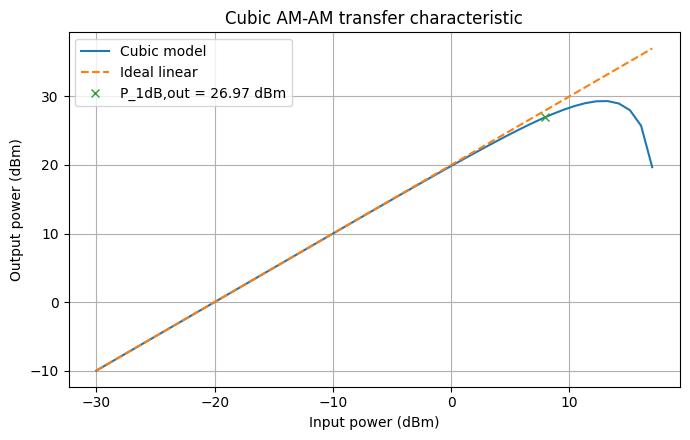

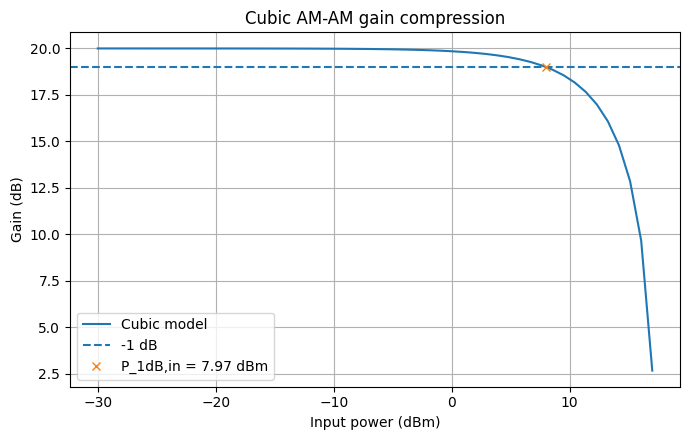

In [8]:
# Locate the 1 dB compression point by linear interpolation of the
# compression curve. compression_db is monotonically increasing through
# the knee, so np.interp solves for the Pin at which it crosses 1 dB.

compression_db = Pout_ideal_dbm - Pout_sweep_dbm
Pin_1dB_in   = np.interp(1.0, compression_db, Pin_sweep_dbm)
Pout_1dB_out = np.interp(Pin_1dB_in, Pin_sweep_dbm, Pout_sweep_dbm)
Gain_1dB     = np.interp(Pin_1dB_in, Pin_sweep_dbm, Gain_sweep_db)

# --- AM-AM (output power vs input power) ---
plt.figure(figsize=(7, 4.5))
plt.plot(Pin_sweep_dbm, Pout_sweep_dbm,         label='Cubic model')
plt.plot(Pin_sweep_dbm, Pout_ideal_dbm,  '--',  label='Ideal linear')
plt.plot(Pin_1dB_in, Pout_1dB_out, 'x',
         label=f'P_1dB,out = {Pout_1dB_out:.2f} dBm')
plt.xlabel('Input power (dBm)')
plt.ylabel('Output power (dBm)')
plt.title('Cubic AM-AM transfer characteristic')
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- Gain compression ---
plt.figure(figsize=(7, 4.5))
plt.plot(Pin_sweep_dbm, Gain_sweep_db,    label='Cubic model')
plt.axhline(G_small_db - 1.0, ls='--',     label='-1 dB')
plt.plot(Pin_1dB_in, Gain_1dB, 'x',
         label=f'P_1dB,in = {Pin_1dB_in:.2f} dBm')
plt.xlabel('Input power (dBm)')
plt.ylabel('Gain (dB)')
plt.title('Cubic AM-AM gain compression')
plt.grid(True)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Rapp Model — Smoothness p = 2

Rapp p=2 | G = 20.00 dB | P1dB_out = 27.00 dBm | P1dB_in = 8.00 dBm
Rapp p=3 | G = 20.00 dB | P1dB_out = 27.00 dBm | P1dB_in = 8.00 dBm
Rapp p=5 | G = 20.00 dB | P1dB_out = 27.00 dBm | P1dB_in = 8.00 dBm


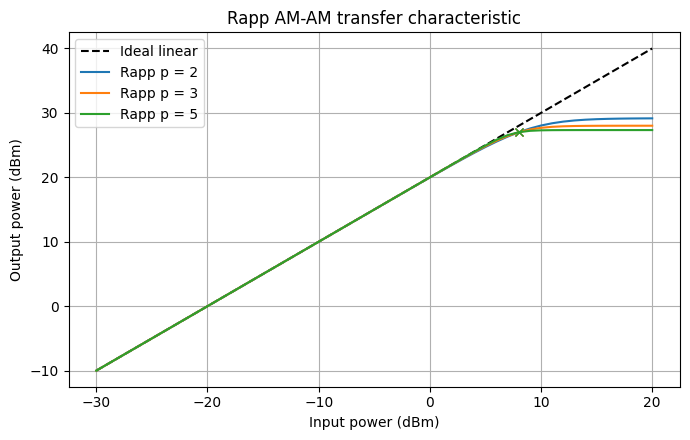

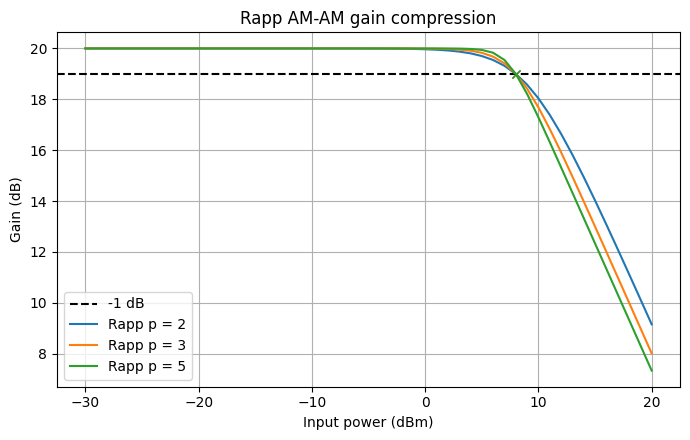

In [9]:
# Sweep the Rapp smoothness factor p and watch how the knee sharpens.
pa = pipe.get("pa")
pa.params.enable_cubic = False

p_values      = [2, 3, 5]
Pin_sweep_dbm = np.linspace(-30, 20, 51)
results       = []

for p_val in p_values:
    pa.params.smoothness_p = p_val
    pa.p = p_val

    # Re-derive Asat for this p so the target output P1dB is preserved
    P1dB_out_w = dbm_to_w(pa.params.p1db_out_dbm)
    r_out_1dB  = np.sqrt(P1dB_out_w)
    c          = 10.0 ** (-1.0 / 20.0)
    r_lin_1dB  = r_out_1dB / c
    pa.Asat    = r_lin_1dB / ((c ** (-2.0 * pa.p) - 1.0) ** (1.0 / (2.0 * pa.p)))

    Pout_sweep_dbm = []
    Gain_sweep_db  = []
    for Pin_dbm_i in Pin_sweep_dbm:
        A_i  = np.sqrt(dbm_to_w(Pin_dbm_i))
        x_i  = A_i * np.exp(1j * 2 * np.pi * f0 * t)
        sig_i = Signal(x=x_i, fs_hz=fs, fc_hz=fc, meta={})
        sig_o, _ = pipe.run(sig_i)
        Pin_meas_i_dbm  = w_to_dbm(np.mean(np.abs(sig_i.x) ** 2))
        Pout_meas_i_dbm = w_to_dbm(np.mean(np.abs(sig_o.x) ** 2))
        Pout_sweep_dbm.append(Pout_meas_i_dbm)
        Gain_sweep_db.append(Pout_meas_i_dbm - Pin_meas_i_dbm)

    Pout_sweep_dbm = np.array(Pout_sweep_dbm)
    Gain_sweep_db  = np.array(Gain_sweep_db)
    G_small_db     = Gain_sweep_db[0]
    Pout_ideal_dbm = Pin_sweep_dbm + G_small_db
    compression_db = Pout_ideal_dbm - Pout_sweep_dbm
    Pin_1dB_in     = np.interp(1.0, compression_db, Pin_sweep_dbm)
    Pout_1dB_out   = np.interp(Pin_1dB_in, Pin_sweep_dbm, Pout_sweep_dbm)
    Gain_1dB       = np.interp(Pin_1dB_in, Pin_sweep_dbm, Gain_sweep_db)

    results.append({
        'p': p_val,
        'Pout': Pout_sweep_dbm,
        'Gain': Gain_sweep_db,
        'Pout_ideal': Pout_ideal_dbm,
        'G_small_db': G_small_db,
        'Pin_1dB_in': Pin_1dB_in,
        'Pout_1dB_out': Pout_1dB_out,
        'Gain_1dB': Gain_1dB,
    })

    print(f"Rapp p={p_val} | G = {G_small_db:.2f} dB | "
          f"P1dB_out = {Pout_1dB_out:.2f} dBm | P1dB_in = {Pin_1dB_in:.2f} dBm")

# Same small-signal gain across p, so one ideal-linear reference is enough
G_ref = results[0]['G_small_db']

# --- AM-AM ---
plt.figure(figsize=(7, 4.5))
plt.plot(Pin_sweep_dbm, results[0]['Pout_ideal'], '--', color='k', label='Ideal linear')
for r in results:
    line, = plt.plot(Pin_sweep_dbm, r['Pout'], label=f"Rapp p = {r['p']}")
    plt.plot(r['Pin_1dB_in'], r['Pout_1dB_out'], 'x', color=line.get_color())
plt.xlabel('Input power (dBm)')
plt.ylabel('Output power (dBm)')
plt.title('Rapp AM-AM transfer characteristic')
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- Gain compression ---
plt.figure(figsize=(7, 4.5))
plt.axhline(G_ref - 1.0, ls='--', color='k', label='-1 dB')
for r in results:
    line, = plt.plot(Pin_sweep_dbm, r['Gain'], label=f"Rapp p = {r['p']}")
    plt.plot(r['Pin_1dB_in'], r['Gain_1dB'], 'x', color=line.get_color())
plt.xlabel('Input power (dBm)')
plt.ylabel('Gain (dB)')
plt.title('Rapp AM-AM gain compression')
plt.grid(True)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()